# Capstone Project

## Imports

In [3]:
import os
import itertools
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg
import random
from sklearn.metrics import jaccard_score
from tabulate import tabulate
from IPython.display import HTML, display
import html
import time

In [2]:
with open("oracle-cards-20260508090243.json", "r", encoding="utf-8") as file:
    FullCardList = json.load(file)

# remove add duplicates explained below ======================================================================
before = len(FullCardList)
print("Total Before Removal: ", before)

itemsRemoved = {}

for c in FullCardList[:]: # copy so we can delete and iterate at same time
    if "//" in c["name"]:
        parts=c["name"].split("//")
        if parts[0].strip() == parts[1].strip():
            itemsRemoved[c["name"]] = c.items()
            FullCardList.remove(c)

print("number of items removed (//): ", len(itemsRemoved))
print("")
print("Total after removal: ", len(FullCardList))
print("Total number of items removed: ", before - (len(FullCardList)))

removeElements = ["set_type",
                  "mtgo_id",
                  "tcgplayer_id",
                  "lang",
                  "released_at",
                  "uri",
                  "scryfall_uri",
                  "highres_image",
                  "image_status",
                  "image_uris",
                  "set_uri",
                  "set_search_uri",
                  "scryfall_set_uri",
                  "rulings_uri",
                  "prints_search_uri",
                  "watermark",
                  "artist",
                  "artist_ids",
                  "illustration_id",
                  "border_color",
                  "frame",
                  "frame_effects",
                  "security_stamp",
                  "full_art",
                  "testless",
                  "booster",
                  "story_spotlight",
                  "related_uris",
                  "purchase_uris",
                  "digital",
                  "foil",
                  "nonfoil",
                  "preview",
                  "games",
                  "finishes",
                  "oversized",
                  "promo",
                  "reprint",
                  "textless"]

for card in FullCardList:
    for key in removeElements:
        card.pop(key,None)

cardsInfo = {card["name"]: card for card in FullCardList}

Total Before Removal:  37442
number of items removed (//):  2189

Total after removal:  35250
Total number of items removed:  2192


## Funcitons

In [3]:
#
# read the text files
# get out the deck list a set of unqinue cards
# and add the cards to the complete snapshot set
#
def readFiletxt(file, cardSet):

    decklist = set()
    
    with open(file, "r", encoding="cp1252") as f:
        for line in f:
            
            if(line.strip() == "Sideboard"):
                break
            else:
                parts = line.split(" ",1)
                #print(parts[1])
                if ( checkLands(parts[1].strip()) ):
                    continue

                else:
                    cardSet.add(parts[1].strip())
                    decklist.add(parts[1].strip())
        
    return decklist, cardSet


#
# read the mwDeck files
# get out the deck list a set of unqinue cards
# and add the cards to the complete snapshot set
#

def readFilemwDeck(file, cardSet):
    decklist = set()
    
    with open(file, "r", encoding="cp1252") as f:
        for line in f:
            #print(line)

            if line.startswith("//"):
                continue

            if line.startswith("SB:"):
                continue
            
            else:
                parts = line.split(" ",2)
                #print(parts[2].strip())
                if ( checkLands(parts[2].strip()) ):
                    continue

                else:
                    cardSet.add(parts[2].strip())
                    decklist.add(parts[2].strip())
        
    return decklist, cardSet

In [4]:
#
# using this method to check cards and see if they are lands
# land cards act as bridges to archtypes that share colour but they themselves dont carry much information,
# since they are required to be in decks they lead to archtypes being condensed together
#
#
def checkLands(checkCard):

    typeLineCheck = ""
    pCards = []

    if "/" in checkCard:
        parts=checkCard.split("/")
        checkCard=parts[0]
        

    # if the card name flat out exists in the dict save it
    if checkCard in cardsInfo:
            typeLineCheck = cardsInfo[checkCard]["type_line"]

    else: # esle try and search for similar
        for c in FullCardList:
            if checkCard.lower() in c["name"].lower():
                pCards.append(c["name"])

        # if only one similar save it
        if (len(pCards) == 1):
            typeLineCheck = cardsInfo[pCards[0]]["type_line"]
                
        
        else:
            #print("+++++++++++++++++++++++++++++++++++++++")
            #print("")
            #print("Error")
            #print("")
            #print(checkCard)
            #print("")
            #print(pCards)
            #print("")
            #print("+++++++++++++++++++++++++++++++++++++++")
            
            #if a card name appears multiple times high likelihood of not being a land
            return False


    if ("Land" in typeLineCheck) and ("//" not in typeLineCheck):
        return True

    else:
        return False
    

In [5]:
#
# this goes into my folders to grab the specific files
# based on file type it uses the correct file reader
# then it prints out the number of total cards and the number of decks
# number of decks used for normalisation
# number of unqiue cards is number of nodes for this snapshot
def getSnapshot(folder):

    snapshotSet = set()
    listOfDecks = []

    for itemMajor in os.listdir(folder):
        #print(itemMajor)
        newpath = os.path.join(folder, itemMajor)
        for itemMinor in os.listdir(newpath):
            #print(itemMinor)
            newestpath = os.path.join(newpath, itemMinor)

            if newestpath.endswith(".mwDeck"):
                temp, snapshotSet = readFilemwDeck(newestpath,snapshotSet)
                listOfDecks.append(temp)
                

            if newestpath.endswith(".txt"):
                temp, snapshotSet = readFiletxt(newestpath,snapshotSet)
                listOfDecks.append(temp)
                


    print("-- Statisitcs --")
    print("   Snapshot               :" , folder)
    print("   number of cards        :" , len(snapshotSet))
    print("   number of Decks        :" , len(listOfDecks))
    print("")
    return snapshotSet, listOfDecks
                
    

In [6]:
##
# use sorted tuples for dictionary to form weighted edge list
# take list of unique cards in each deck
# increase dicitonary value for each time a pair appears
# return this dictionary and a dictionary of each time a card appears
#

def makeEdgeList(decks):

    countPairs = {} #dicitonary of pairs of cards (SORT ALPHABETICALLY) count of pairs appearance
    countCards = {} #dict of cards appearance 

    for deck in decks:
        for card in deck:
            if card not in countCards:
                countCards[card] = 1

            else:
                countCards[card] += 1


        for pairs in itertools.combinations(deck,2):
            pairs = tuple(sorted(pairs))
            
            if pairs not in countPairs:
                countPairs[pairs] = 1

            else:
                countPairs[pairs] += 1

    return countCards, countPairs
    

In [7]:
#
#
# make graphs
# make an undirected weighted graph 
#
def makeUndirectedGraph(edges, noDecks):

    G = nx.Graph()
    for key in edges:

        G.add_edge(key[0],key[1],weight = edges[key]/noDecks) # edges are normalised by => pair appearances /total number of decks

    return G

#
# directed weighted graph
#
def makeDirectedGraph(edges, cards):

    G = nx.DiGraph()
    for key in edges:

        # (from_node , to_node) 
        # probablity of to_node, given from_node
        temp = edges[key]/ cards[key[0]]
        G.add_edge(key[0],key[1],weight=temp)

        temp = edges[key]/ cards[key[1]]
        G.add_edge(key[1],key[0],weight=temp)

    return G
    

### Graph Functions (Networks)

In [8]:
def drawGraph(G,p):

    plt.figure(figsize=(30,30))

    nodeColors="blue"

    pos = nx.spring_layout(G, k=1, iterations=10,seed=39)
    #pos = nx.kamada_kawai_layout(G)

    colourList = ["red",
                 "blue",
                 "green",
                 "skyblue",
                 "orange",
                 "yellow",
                 "purple",
                 "grey",
                 "lightgreen",
                 "pink",
                  "lime",
                  "cyan",
                  "coral",
                 ]

    nodeColors = [colourList[p[node]] for node in G.nodes()]
    
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_size = 500,
        node_color = nodeColors
    )
    plt.show()
    

In [9]:
def getlouvainPart(G, cards, r= True, seed = 39):

    outputDict = {}
    
    random.seed(seed)
    p = community_louvain.best_partition(G, randomize = r) #get louvian partition
    #print number of communtieis and paritions
    print("Number of communities : " , len(set(p.values()))) 
    tempScore = community_louvain.modularity(p, G)
    print("Modularity Score      : " ,  tempScore)
    print("")

    for i in set(p.values()):
        temp = []

        for node in p:
            if p[node] == i:
                temp.append((node, cards[node]))

        # print top 10 per community
        print("  ===== Communitiy ", i ," =====")

        sortedD = sorted(temp, key= lambda x: x[1], reverse=True)
        print(len(sortedD))
                
        if len(sortedD) > 10:
            x = 0
            while (x < 10):
                print(sortedD[x])
                x +=1

        if len(sortedD) <= 10:
            x = 0
            while (x < len(sortedD)):
                print(sortedD[x])
                x +=1

        outputDict["com" + str(i)] = sortedD
        print("")
        print("")
        print("")
    return p , outputDict


def getleidenPart(G, cards):
    return 0


    

In [1]:

#### consensus cluster Louvain
#
#
#
#

# main body of consensus
def getlouvain(G):
     return community_louvain.best_partition(G)
# function to call louvain and then take the partition and build up the adjacency matrix

def consensusLouvain(G, noTimes, threshold, iterations):
    going = True
    output = 0
    count = 0
    while(going):

        
        tempEL = {}
        #apply louv to G a number of times
        for n in range(noTimes):
            tempP = getlouvain(G)

            #build a matrix from this continuousley adding 
            for pairs in itertools.combinations(tempP.keys(),2):
                
                pairs = tuple(sorted(pairs))
                #if both nodes are in the same partition
                if tempP[pairs[0]] == tempP[pairs[1]]:
                    if pairs not in tempEL:
                        tempEL[pairs] = 1

                    else:
                        tempEL[pairs] += 1
    

        tempEL = {pair: count for pair, count in tempEL.items() if count >= threshold}
        G = makeUndirectedGraph(tempEL, noTimes)

        
        output = getlouvain(G)

        
        if count > iterations:
            going = False
        else:
            count += 1
            #print(count)

    finalpartition = output
    return finalpartition
    
    
#main body where all the usefull information is printed out post consensus
def getlouvainPart2(G, cards):
    #random.seed(seed)

    
    
    #p = community_louvain.best_partition(G, randomize = r)
    p = consensusLouvain(G, 150, 30, 50)


    # ========== finalised scores and communities ==========
    outputDict = {}
    print("Number of communities : " , len(set(p.values())))
    tempScore = community_louvain.modularity(p, G)
    print("Modularity Score      : " ,  tempScore)
    print("")

    for i in set(p.values()):
        temp = []

        for node in p:
            if p[node] == i:
                temp.append((node, cards[node]))


        print("  ===== Communitiy ", i ," =====")

        sortedD = sorted(temp, key= lambda x: x[1], reverse=True)
        print(len(sortedD))
                
        if len(sortedD) > 10:
            x = 0
            while (x < 10):
                print(sortedD[x])
                x +=1

        if len(sortedD) <= 10:
            x = 0
            while (x < len(sortedD)):
                print(sortedD[x])
                x +=1

        outputDict["com" + str(i)] = sortedD
        print("")
        print("")
        print("")
    return p , outputDict, tempScore
    
    #so run louvain 100s of times
#store results in a matrix
#build a graph using said matrics with the edges between them being Aij / total runs

In [11]:
def getPagerank(G, seePRNumber, coms):

    #get the pageranks for all cards
    p = nx.pagerank(G, weight="weight")
    pSorted = sorted(p.items(), key=lambda x: x[1], reverse=True)

    #print out the top 10
    print("             Top ",seePRNumber," cards by Page Rank Overall")
    x = 0
    while x < seePRNumber:
        print(pSorted[x])
        x +=1

    print("")
    print("")
    print("")


    #top 10 pageranks per communtiy
    
    for i in set(coms.values()):
        temp = []

        for node in coms:
            if coms[node] == i:
                temp.append((node, p[node]))
        print("  ===== Communitiy ", i ," =====")

        sortedD = sorted(temp, key= lambda x: x[1], reverse=True)
        print(len(sortedD))
                
        if len(sortedD) > 10:
            x = 0
            while (x < 10):
                print(sortedD[x])
                x +=1

        if len(sortedD) <= 10:
            x = 0
            while (x < len(sortedD)):
                print(sortedD[x])
                x +=1
                
        print("")
        print("")
        print("")
        
    return p

    

In [12]:

#
# print out the useful and main statistics of the graph
# prints out information based on graph type (directed/undirected)
#
def graphStats(G):

    # universal stats =========================================================
    noNodes = G.number_of_nodes()
    noEdges = G.number_of_edges()
    density = nx.density(G)

    print("number of Nodes                          : " , noNodes)
    print("number of Edges                          : " , noEdges)
    print("density (fraction of all possible nodes) : " , density)

    # undirected stats ===================================================
    if not nx.is_directed(G): #undirected 
        avgDegree = 0
        for node, deg in G.degree:
            avgDegree += deg

        avgDegree = avgDegree/noNodes
        print("Average degree                           : ", avgDegree)

        
        avgEdgeW = 0
        temp = G.edges(data=True)
        for n in temp:
            avgEdgeW += n[2]["weight"]

        avgEdgeW = avgEdgeW/noEdges
        print("Average Edge Weight                      : ", avgEdgeW)

        


    #directed stats===========================================
    else:
        avgInDegree = 0
        for node, value in G.in_degree():
            avgInDegree += value

        avgInDegree = avgInDegree/noNodes
        print("Average In degree                         : ", avgInDegree)
        
        avgOutDegree = 0
        for node, value in G.out_degree():
            avgOutDegree += value

        avgOutDegree = avgOutDegree/noNodes
        print("Average Out degree                        : ", avgOutDegree)
    

    #number of connected components
    
    print("")
    print("")
    return noNodes
    

### Main body function

In [43]:
def snapToGraph(pathway, cardSetSoFar):

    cardsInSnap = set()

    #parse the snapshot and get a set of all the cards
    # and a list of sets of all the decks
    # i.e each deck but only the unique cards in said deck
    cardset, decks = getSnapshot(pathway)

    #get card occurances
    #get pairwise occurances
    cardsOcc, pairsOcc = makeEdgeList(decks)


    #return the updated cards set
    cardSetSoFar.update(cardset) # this is so we have a set which can be built upon and will contain all cards period
    cardsInSnap.update(cardset) # this is so we have a set of exclusively this snapshot
    #print("length : ", len(decks))
    print("# cards that have appeared so far :", len(cardSetSoFar))

    graph = makeUndirectedGraph(pairsOcc, len(decks) )
    digraph = makeDirectedGraph(pairsOcc, cardsOcc)

    print("")
    print("------------- Undirected Graph Stats -------------")
    graphStats(graph)
    comms, commsDict, modularity = getlouvainPart2(graph, cardsOcc)


    print("")
    print("------------- Directed Graph Stats -------------")
    graphStats(digraph)

    cardsPageRank = getPagerank(digraph, 10, comms)

    
    cardsOccNorm = cardsOcc.copy()
    for name,x in cardsOccNorm.items():
        cardsOccNorm[name]= x /len(decks)

    # graph
    # digraph = directed graph
    # cardSetSoFar =  continuous set of cards that will be added to with each subsequent snapshot
    # cardsOcc = dictionary of cards and that cards number of occurances
    # commsDict = dictionary of communities
    # cardsInSnap = set of cards in this specific snapshot
    # cardsPageRank = dict of cards in this snpashot and thier pagerank
    # cardsOccNorm = dict of cards in this snpashot and thier occurance normalised
    return graph, digraph, cardSetSoFar, cardsOcc, commsDict, cardsInSnap, cardsPageRank, cardsOccNorm, modularity

### Comparison functions

In [14]:
# do jaccaard similairity
# set intersection over union
def jaccardSim(com1, com2, verbose):

    temp1 = []
    for x in com1:
        temp1.append(x[0])

    temp2 = []
    for x in com2:
        temp2.append(x[0])
    
    set1 = set(temp1)
    set2= set(temp2)
    
    top = len( (set1).intersection(set2) )
    bot = len( (set1).union(set2) )

    if(verbose):
        print(top)
        print(bot)
        print((set1).intersection(set2))
    return top/bot, top

In [15]:
def removeFromSet(RemoveFrom,beingRemoved):
    temp1 = []
    for x in beingRemoved:
        temp1.append(x[0]) # this is now a clean without scores

    return RemoveFrom - set(temp1)

def compareIntersect(comparison1, comparison2):
    temp1 = []
    for x in comparison2:
        temp1.append(x[0]) # this is now a clean without scores
    return len(comparison1.intersection(set(temp1)))
    

In [16]:
def jaccardTable(i,j, snap1, cards1, snap2, cards2):
    #compare all of the two snapshots communities

    total = cards1.union(cards2) # every unique card in both snapshots
    finalCardTotal = 0
    
    tab = [] #this is what will be printed out using tabulate
    for name1,x in snap1.items():
        temp = []
        headings = [] # keep track of headings
        headings.append(str(i) + "\\" + str(j)) 
        headings.append("# in Community")
        temp.append(name1)
        temp.append(len(x))
        cardsAccountedFor = 0
        tempTotal = total.copy() # copy over so I can reuse
        
        for name2,y in snap2.items():
            
            tempTotal = removeFromSet(tempTotal,y) #converts dictionary with scores into a list
            headings.append(name2)
            out, add = jaccardSim(x, y, False) #print "out". sum "add" to make sure all cards are accounted for
            cardsAccountedFor += add # using this to account for all cards
            temp.append(out) 
            

        #adding outputs to finalised table 
        temp.append(cardsAccountedFor)
        tempintersect = compareIntersect(tempTotal, x)
        temp.append(tempintersect)
        finalCardTotal += cardsAccountedFor + tempintersect
        tab.append(temp)
    # and addtional styling 
    headings.append("Cards Accounted For")
    headings.append("Cards Unaccounted For")
    outputTable = tabulate(tab, headers=headings, tablefmt="grid")

    #code to make tables scrollable
    display(HTML(f"""
    </div style="overflow-x: auto; width:100%;">
    <pre style="white-space:pre; font-family:monospace;">{html.escape(outputTable)}</pre>
    
    </div>
    """))
    return finalCardTotal

## Graphing functions (Temporal)

In [44]:
#
# graphing a specific card over time 
# uses either pagerank or normalised occurances
#
def graphOverTime(Cardname, stats):

    temp = []
    for x in stats:
        if Cardname in x:
            temp.append(x[Cardname])

        else:
            temp.append(None)

    plt.plot(range(len(temp)), temp, marker="o")
    plt.xticks(range(len(temp)))
    plt.show()
    return temp


def graphSnapshotsOverTime(scores):
    plt.plot(range(len(scores)), scores, marker="o")
    plt.xticks(range(len(scores)))
    plt.show()
    return temp

## Rough work

### test land checker

In [18]:
print(checkLands("Gohn, Town of Ruin")) #card
print("True") 
print("")

print(checkLands("Treasure Map") )
print("False") 
print("")

print(checkLands("Matzalantli")) #card
print("False") #expected result
print("")

print(checkLands("Matzalantli, the great door")) #card
print("False") #expected result
print("")

print(checkLands("Mountain"))
print("True") #expected result
print("")

True
True

False
False

False
False

False
False

True
True



### Run all Snapshots

In [19]:
totalcards = set()
pageranks = []
cardOccurancesNorm = []
modularity = []
numberOfCommunities = []
g1, diG1, totalcards, cardOccurances1, communityList1, snap1Cards, pagerank1, cardOccurancesNorm1, mod1 = snapToGraph("decklists\\Snapshot 1", totalcards)
pageranks.append(pagerank1)
cardOccurancesNorm.append(cardOccurancesNorm1)
modularity.append(mod1)
numberOfCommunities.append(len(communityList1))


-- Statisitcs --
   Snapshot               : decklists\Snapshot 1
   number of cards        : 403
   number of Decks        : 697

# cards that have appeared so far : 403

------------- Undirected Graph Stats -------------
number of Nodes                          :  403
number of Edges                          :  5852
density (fraction of all possible nodes) :  0.07224423786773329
Average degree                           :  29.042183622828784
Average Edge Weight                      :  0.01186341031919769


Number of communities :  9
Modularity Score      :  0.6068356204927803

  ===== Communitiy  0  =====
11
('Draconautics Engineer', 8)
("Agatha's Soul Cauldron", 7)
('Burnout Bashtronaut', 7)
('Searslicer Goblin', 7)
('Krenko, Mob Boss', 7)
('Howlsquad Heavy', 7)
('Rundvelt Hordemaster', 7)
('Greasewrench Goblin', 6)
('Fanatical Firebrand', 5)
('Dropkick Bomber', 4)



  ===== Communitiy  1  =====
59
('Get Lost', 139)
('Temporary Lockdown', 129)
('Beza, the Bounding Spring', 122)
('Ov

In [20]:
g2, diG2, totalcards, cardOccurances2, communityList2 , snap2Cards, pagerank2, cardOccurancesNorm2, mod2  = snapToGraph("decklists\\Snapshot 2", totalcards)
pageranks.append(pagerank2)
cardOccurancesNorm.append(cardOccurancesNorm2)
modularity.append(mod2)
numberOfCommunities.append(len(communityList2))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 2
   number of cards        : 415
   number of Decks        : 986

# cards that have appeared so far : 565

------------- Undirected Graph Stats -------------
number of Nodes                          :  415
number of Edges                          :  6530
density (fraction of all possible nodes) :  0.07601420173447412
Average degree                           :  31.46987951807229
Average Edge Weight                      :  0.011464173777449276


Number of communities :  7
Modularity Score      :  0.5370680172046391

  ===== Communitiy  0  =====
102
('Preacher of the Schism', 198)
('Go for the Throat', 197)
('Sheoldred, the Apocalypse', 191)
('Cut Down', 168)
('Spyglass Siren', 159)
('Duress', 145)
('Anoint with Affliction', 125)
('Deep-Cavern Bat', 119)
('Kaito, Bane of Nightmares', 110)
("Gix's Command", 106)



  ===== Communitiy  1  =====
36
('Pawpatch Recruit', 6)
('Haywire Mite', 6)
('Brightglass Gearhulk', 3)
('Sandst

In [21]:
g3, diG3, totalcards, cardOccurances3, communityList3 , snap3Cards, pagerank3, cardOccurancesNorm3, mod3  = snapToGraph("decklists\\Snapshot 3", totalcards)
pageranks.append(pagerank3)
cardOccurancesNorm.append(cardOccurancesNorm3)
modularity.append(mod3)
numberOfCommunities.append(len(communityList3))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 3
   number of cards        : 213
   number of Decks        : 210

# cards that have appeared so far : 594

------------- Undirected Graph Stats -------------
number of Nodes                          :  213
number of Edges                          :  2289
density (fraction of all possible nodes) :  0.10138187616263619
Average degree                           :  21.492957746478872
Average Edge Weight                      :  0.029742661590631488


Number of communities :  5
Modularity Score      :  0.6222757942327988

  ===== Communitiy  0  =====
53
("Agatha's Soul Cauldron", 9)
('Overlord of the Balemurk', 8)
('Rubblebelt Maverick', 7)
('Town Greeter', 7)
('Llanowar Elves', 6)
('Elspeth, Storm Slayer', 5)
('Cache Grab', 5)
('Disruptive Stormbrood', 5)
('Scavenging Ooze', 5)
('Haywire Mite', 5)



  ===== Communitiy  1  =====
67
('Temporary Lockdown', 25)
('Marang River Regent', 17)
("Ephara's Dispersal", 15)
('Roiling Drago

In [22]:
g4, diG4, totalcards, cardOccurances4, communityList4, snap4Cards, pagerank4, cardOccurancesNorm4, mod4 = snapToGraph("decklists\\Snapshot 4", totalcards)
pageranks.append(pagerank4)
cardOccurancesNorm.append(cardOccurancesNorm4)
modularity.append(mod4)
numberOfCommunities.append(len(communityList4))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 4
   number of cards        : 423
   number of Decks        : 325

# cards that have appeared so far : 704

------------- Undirected Graph Stats -------------
number of Nodes                          :  423
number of Edges                          :  5764
density (fraction of all possible nodes) :  0.0645804622813799
Average degree                           :  27.252955082742318
Average Edge Weight                      :  0.014482997918111327


Number of communities :  8
Modularity Score      :  0.613407360966809

  ===== Communitiy  0  =====
14
('Assimilation Aegis', 2)
('Ishgard, the Holy See', 2)
('Braided Net', 1)
('Cryptic Coat', 1)
('Perilous Snare', 1)
('Spring-Loaded Sawblades', 1)
('United Battlefront', 1)
('Candy Trail', 1)
('Thousand Moons Smithy', 1)
('Clay-Fired Bricks', 1)



  ===== Communitiy  1  =====
105
('Get Lost', 46)
('Beza, the Bounding Spring', 30)
('Overlord of the Mistmoors', 28)
('Elspeth, Storm 

In [23]:
g5, diG5, totalcards, cardOccurances5, communityList5, snap5Cards, pagerank5, cardOccurancesNorm5, mod5 = snapToGraph("decklists\\Snapshot 5", totalcards)
pageranks.append(pagerank5)
cardOccurancesNorm.append(cardOccurancesNorm5)
modularity.append(mod5)
numberOfCommunities.append(len(communityList5))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 5
   number of cards        : 211
   number of Decks        : 184

# cards that have appeared so far : 752

------------- Undirected Graph Stats -------------
number of Nodes                          :  211
number of Edges                          :  2153
density (fraction of all possible nodes) :  0.09717896637327916
Average degree                           :  20.407582938388625
Average Edge Weight                      :  0.03201044043700467


Number of communities :  5
Modularity Score      :  0.6689417651925353

  ===== Communitiy  0  =====
24
('Abrade', 71)
('Into the Flood Maw', 61)
('Winternight Stories', 56)
('Quantum Riddler', 55)
("Agatha's Soul Cauldron", 52)
('Vivi Ornitier', 52)
('Fear of Missing Out', 52)
('Steamcore Scholar', 52)
("Proft's Eidetic Memory", 52)
('Marauding Mako', 50)



  ===== Communitiy  1  =====
70
('Get Lost', 35)
('Stock Up', 31)
('Seam Rip', 29)
('Consult the Star Charts', 29)
('Marang R

In [24]:
g6, diG6, totalcards, cardOccurances6, communityList6, snap6Cards, pagerank6, cardOccurancesNorm6, mod6 = snapToGraph("decklists\\Snapshot 6", totalcards)
pageranks.append(pagerank6)
cardOccurancesNorm.append(cardOccurancesNorm6)
modularity.append(mod6)
numberOfCommunities.append(len(communityList6))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 6
   number of cards        : 349
   number of Decks        : 542

# cards that have appeared so far : 825

------------- Undirected Graph Stats -------------
number of Nodes                          :  349
number of Edges                          :  4236
density (fraction of all possible nodes) :  0.0697559529690742
Average degree                           :  24.275071633237822
Average Edge Weight                      :  0.016626072776307954


Number of communities :  6
Modularity Score      :  0.6662764738988718

  ===== Communitiy  0  =====
49
('Hired Claw', 124)
('Screaming Nemesis', 120)
('Burst Lightning', 119)
('Burnout Bashtronaut', 116)
('Razorkin Needlehead', 116)
('Nova Hellkite', 116)
('Lightning Strike', 110)
('Witchstalker Frenzy', 101)
('Emberheart Challenger', 101)
('Scalding Viper', 45)



  ===== Communitiy  1  =====
72
('Spyglass Siren', 110)
('Floodpits Drowner', 102)
('Bitter Triumph', 95)
('Tragic Tra

In [25]:
g7, diG7, totalcards, cardOccurances7, communityList7, snap7Cards, pagerank7, cardOccurancesNorm7, mod7 = snapToGraph("decklists\\Snapshot 7", totalcards)
pageranks.append(pagerank7)
cardOccurancesNorm.append(cardOccurancesNorm7)
modularity.append(mod7)
numberOfCommunities.append(len(communityList7))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 7
   number of cards        : 524
   number of Decks        : 889

# cards that have appeared so far : 979

------------- Undirected Graph Stats -------------
number of Nodes                          :  524
number of Edges                          :  8729
density (fraction of all possible nodes) :  0.06370323880139536
Average degree                           :  33.31679389312977
Average Edge Weight                      :  0.008171693053203513


Number of communities :  7
Modularity Score      :  0.59868371677091

  ===== Communitiy  0  =====
73
('Bitter Triumph', 150)
('Shoot the Sheriff', 119)
('Spyglass Siren', 105)
('Floodpits Drowner', 100)
("Tishana's Tidebinder", 96)
('Enduring Curiosity', 96)
('Deep-Cavern Bat', 94)
('Kaito, Bane of Nightmares', 93)
('Stab', 90)
('Cecil, Dark Knight', 88)



  ===== Communitiy  1  =====
64
('Boomerang Basics', 263)
('Quantum Riddler', 258)
("Stormchaser's Talent", 257)
('Torch the T

In [26]:
g8, diG8, totalcards, cardOccurances8, communityList8, snap8Cards, pagerank8, cardOccurancesNorm8, mod8 = snapToGraph("decklists\\Snapshot 8", totalcards)
pageranks.append(pagerank8)
cardOccurancesNorm.append(cardOccurancesNorm8)
modularity.append(mod8)
numberOfCommunities.append(len(communityList8))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 8
   number of cards        : 410
   number of Decks        : 678

# cards that have appeared so far : 1050

------------- Undirected Graph Stats -------------
number of Nodes                          :  410
number of Edges                          :  6267
density (fraction of all possible nodes) :  0.07474506529906375
Average degree                           :  30.570731707317073
Average Edge Weight                      :  0.011177149775030995


Number of communities :  5
Modularity Score      :  0.5409539722539105

  ===== Communitiy  0  =====
92
('Stock Up', 162)
('Requiting Hex', 148)
('Bitter Triumph', 145)
('Winternight Stories', 111)
('Deceit', 106)
('Superior Spider-Man', 87)
('Shoot the Sheriff', 73)
('Harvester of Misery', 73)
('Enduring Curiosity', 72)
('Floodpits Drowner', 66)



  ===== Communitiy  1  =====
75
('Sear', 76)
('Nova Hellkite', 63)
('Hired Claw', 40)
('Shock', 33)
('Hexing Squelcher', 32)
('Lightn

In [ ]:
print(" ==== Modularity scores of the snapshots over time ====")
graphSnapshotsOverTime(modularity)

print(" ==== Number of Communities in each snapshot ====")
graphSnapshotsOverTime(numberOfCommunities)

5

### Graphing all banned Cards

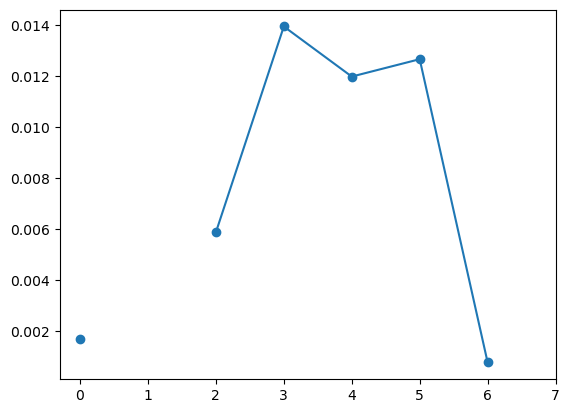

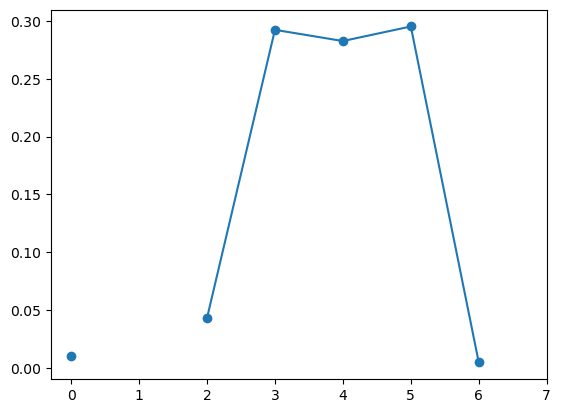

In [40]:
#Dragonhawk, Fate's Tempest 

# FIRST BANS 
# "Cori-Steel Cutter"
# "Abuelo's Awakening"
# "Monstrous Rage"
# "Heartfire Hero"
# "Up the Beanstalk"
# "Hopeless Nightmare"
# "This Town Ain't Big Enough"
#
# SECCOND BANS
# "Vivi Ornitier"
# "Proft's Eidetic Memory"
# "Screaming Nemesis"
#
#
#
a = graphOverTime("Agatha's Soul Cauldron", pageranks)
a = graphOverTime("Agatha's Soul Cauldron", cardOccurancesNorm)

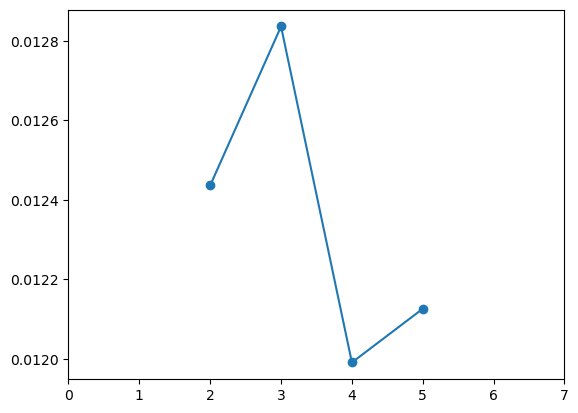

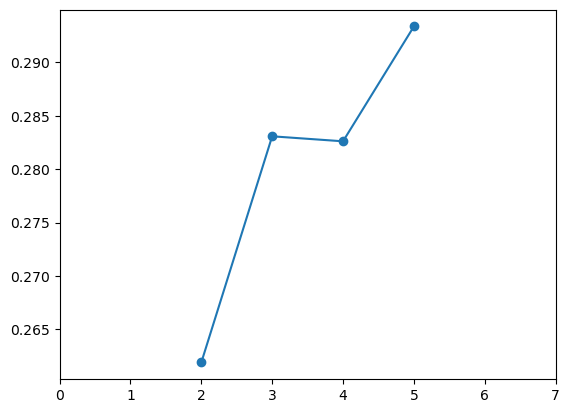

In [41]:
a = graphOverTime("Vivi Ornitier", pageranks)
a = graphOverTime("Vivi Ornitier", cardOccurancesNorm)

### Jaccard Tables

In [29]:
jaccardTable(1,2, communityList1, snap1Cards, communityList2, snap2Cards)

403

In [30]:
jaccardTable(2,3, communityList2, snap2Cards, communityList3, snap3Cards)

415

In [31]:
jaccardTable(3,4, communityList3, snap3Cards, communityList4, snap4Cards)

213

In [32]:
jaccardTable(4,5, communityList4, snap4Cards, communityList5, snap5Cards)

423

### Rough work

In [5]:
#start =time.time()
#getlouvainPart2(True, g1,cardOccurances1)
#print(f"took {time.time() - start:.2f} secconds")

"""
consensusLouvain(G, 150, 20, 50)
Number of communities :  9
Modularity Score      :  0.6068 485472749645

consensusLouvain(G, 120, 20, 40)
Number of communities :  9
Modularity Score      :  0.6068 485472749645
Number of communities :  9
Modularity Score      :  0.6068 356204927805
Number of communities :  9
Modularity Score      :  0.6068 485472749645
Number of communities :  9
Modularity Score      :  0.6068 485472749646
Number of communities :  9
Modularity Score      :  0.6068 490670282987

(G, 120, 20, 20)
Number of communities :  10
Modularity Score      :  0.6068814711075718
Number of communities :  10
Modularity Score      :  0.6068814711075718
Number of communities :  9
Modularity Score      :  0.6068485472749645


threshold of 20 (100 - 10)
Number of communities :  10
Modularity Score      :  0.6070167854928531
Number of communities :  10
Modularity Score      :  0.6070812684318734


threshold of 15 (120 - 15)
Number of communities :  9
Modularity Score      :  0.6068356204927804
Number of communities :  9
Modularity Score      :  0.6068485472749645
Number of communities :  10
Modularity Score      :  0.6068685443253877

"""

'\nconsensusLouvain(G, 150, 20, 50)\nNumber of communities :  9\nModularity Score      :  0.6068 485472749645\n\nconsensusLouvain(G, 120, 20, 40)\nNumber of communities :  9\nModularity Score      :  0.6068 485472749645\nNumber of communities :  9\nModularity Score      :  0.6068 356204927805\nNumber of communities :  9\nModularity Score      :  0.6068 485472749645\nNumber of communities :  9\nModularity Score      :  0.6068 485472749646\nNumber of communities :  9\nModularity Score      :  0.6068 490670282987\n\n(G, 120, 20, 20)\nNumber of communities :  10\nModularity Score      :  0.6068814711075718\nNumber of communities :  10\nModularity Score      :  0.6068814711075718\nNumber of communities :  9\nModularity Score      :  0.6068485472749645\n\n\nthreshold of 20 (100 - 10)\nNumber of communities :  10\nModularity Score      :  0.6070167854928531\nNumber of communities :  10\nModularity Score      :  0.6070812684318734\n\n\nthreshold of 15 (120 - 15)\nNumber of communities :  9\nMo

In [34]:
##
# Reccomendation funcitons 
#
#

def readFileR(file):

    decklist = []
    
    with open(file, "r", encoding="cp1252") as f:
        for line in f:
            if(line.strip() == "Sideboard"):
                continue
            
            parts = line.split(" ",1)
            #print(parts[1])
            for x in range(int(parts[0].strip())):
                decklist.append(parts[1].strip())
        
    return decklist

#
# Return a list that reccomends top 10 based on weight of edges
#
def top10addition(G, decklist):
    reccomendations = {}

    # so we want to get the cards related to x
    for x in decklist:
        if (checkLands(x)):
            continue
        else:
            neighbours = list(G.neighbors(x))

            for y in neighbours:
                if y in decklist:
                    continue
                    
                weight = G[x][y]["weight"]
                #print(y , weight)

                if y in reccomendations:
                    reccomendations[y] += weight
                else:
                    reccomendations[y] = weight
                

    reccomendations = sorted(reccomendations.items(), key=lambda x: x[1], reverse= True)

    print("  ==== Reccomend Cards based on Edges ====")
    print("")
    for x in range(10):
        print(reccomendations[x][0])

    print("")
    print("")
            
    return reccomendations
    

##
# main body funciton to run all reccomendation methods
# takes decklist from a file
# suggests 10 reccomendations
#
def Reccomender(G, pathway):

    deck = readFileR(pathway)

    out1 = top10addition(G, deck)

    
    return 0





In [35]:
tester = ["Imodane's Recruiter", "Voldaren Thrillseeker", 
          "Resolute Reinforcements",'Kaito, Bane of Nightmares',
          'Nowhere to Run', "Draconautics Engineer",
          "Agatha's Soul Cauldron",'Chainsaw',"Warleader's Call" ]
#top10addition(g1, tester)

#"Warleader's Call": 0.00860832137733142,

In [36]:
out = Reccomender(g6, "Reccommender\\Reccommender 1.txt")

  ==== Reccomend Cards based on Edges ====

Kaito, Bane of Nightmares
Preacher of the Schism
Phantom Interference
Tishana's Tidebinder
Stab
Shoot the Sheriff
Deep-Cavern Bat
Essence Scatter
Faebloom Trick
Pawpatch Recruit




In [133]:
def searchNewComs(commingFrom, goingTo, listOfCards, NewComs):
    # take the listOfCards 
    # search through the communities in NewComs
    # assuming listOfCards was the cards deemed to be most important of a particular community 
    # in the previous snapshot I can track adn see where they all ended up

    for x, y in enumerate(listOfCards):
        if isinstance(y,tuple):
            listOfCards[x] = y[0]
        
    print("")
    print("           Original Community's most important cards")
    print("")

    for k in range(len(listOfCards)):
        print(listOfCards[k])
    
    print("")
    print(f"          Going From Snapshot {commingFrom} into Snapshot {goingTo}")
    print("")
    print("")
    

    notAppearing = listOfCards.copy()
    notAppearing = set(notAppearing)
    
    for keys, c in NewComs.items():

        
        output = []
        
        temp = []
        for y in c:
            temp.append(y[0])

        #print(temp)
        for x in listOfCards:
            
           
            if x in temp:
                output.append(x)


        print(f"===  {keys} ===")
        for i in range(len(output)):
            print(output[i])
            #print(notAppearing)
            notAppearing.discard(output[i])

        print("")
        print("")


    if len(notAppearing) == 0:
        print(f"All cards survived and appeared in one of the communities")

    else:
        print(f" cards that did not appear in snapshot {goingTo}")
    
        for item in notAppearing:
            print(item)

        print("")
                


In [134]:
search= ['Monstrous Rage', 'Emberheart Challenger', 'Heartfire Hero', 'Manifold Mouse','Screaming Nemesis'
         , 'Burst Lightning', 'Hired Claw','Witchstalker Frenzy', 'Torch the Tower','Lightning Strike']


search2 = [
('Draconautics Engineer', 8),
("Agatha's Soul Cauldron", 7),
('Burnout Bashtronaut', 7),
('Searslicer Goblin', 7),
('Krenko, Mob Boss', 7),
('Howlsquad Heavy', 7),
('Rundvelt Hordemaster', 7),
('Greasewrench Goblin', 6),
'Fanatical Firebrand', 'Dropkick Bomber'
]

searchNewComs(1,2,search2, communityList2)


           Original Community's most important cards

Draconautics Engineer
Agatha's Soul Cauldron
Burnout Bashtronaut
Searslicer Goblin
Krenko, Mob Boss
Howlsquad Heavy
Rundvelt Hordemaster
Greasewrench Goblin
Fanatical Firebrand
Dropkick Bomber

          Going From Snapshot 1 into Snapshot 2


===  com0 ===


===  com1 ===


===  com2 ===


===  com3 ===


===  com4 ===


===  com5 ===


===  com6 ===
Draconautics Engineer
Greasewrench Goblin


 cards that did not appear in snapshot 2
Burnout Bashtronaut
Agatha's Soul Cauldron
Fanatical Firebrand
Searslicer Goblin
Krenko, Mob Boss
Howlsquad Heavy
Dropkick Bomber
Rundvelt Hordemaster



In [135]:
search3 = [
    ('Monstrous Rage', 0.026628723779765492),
('Burst Lightning', 0.01594578735806465),
('Screaming Nemesis', 0.014769567238329406),
('Emberheart Challenger', 0.013261613491100258),
('Heartfire Hero', 0.013050920615558527),
('Magebane Lizard', 0.012783799983455944),
('Manifold Mouse', 0.012502636991211298),
('Hired Claw', 0.012484470619097562),
('Monastery Swiftspear', 0.00946868268864054),
('Witchstalker Frenzy', 0.009376307588447418)
]
searchNewComs(3,4,search3, communityList4)


           Original Community's most important cards

Monstrous Rage
Burst Lightning
Screaming Nemesis
Emberheart Challenger
Heartfire Hero
Magebane Lizard
Manifold Mouse
Hired Claw
Monastery Swiftspear
Witchstalker Frenzy

          Going From Snapshot 3 into Snapshot 4


===  com0 ===


===  com1 ===


===  com2 ===
Burst Lightning
Screaming Nemesis
Emberheart Challenger
Manifold Mouse
Hired Claw
Monastery Swiftspear
Witchstalker Frenzy


===  com3 ===


===  com4 ===


===  com5 ===


===  com6 ===


===  com7 ===


 cards that did not appear in snapshot 4
Magebane Lizard
Heartfire Hero
Monstrous Rage

